<a href="https://colab.research.google.com/github/ellenwang995/PriceAtThePump/blob/main/PumpPricesV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
import numpy as np

In [13]:
#Loading the Data

#Weekly NY Gas Prices ($ per gallon) from EIA
ny_gas = pd.read_excel('EMM_EPM0_PTE_Y35NY_DPGw.xls', sheet_name='Data 1', header=2)
ny_gas.columns = ['Date', 'NY_Gas']
ny_gas['Date'] = pd.to_datetime(ny_gas['Date'])

#Weekly Brent Crude Prices ($ per barrel) from EIA
brent = pd.read_excel('RBRTEw.xls', sheet_name='Data 1', header=2)
brent.columns = ['Date', 'Brent']
brent['Date'] = pd.to_datetime(brent['Date'])

#Merge the two sets of data
df = pd.merge_asof(ny_gas, brent, on='Date')
df = df.sort_values('Date').reset_index(drop=True)

#Setting Date as an Index
df = df.set_index('Date')

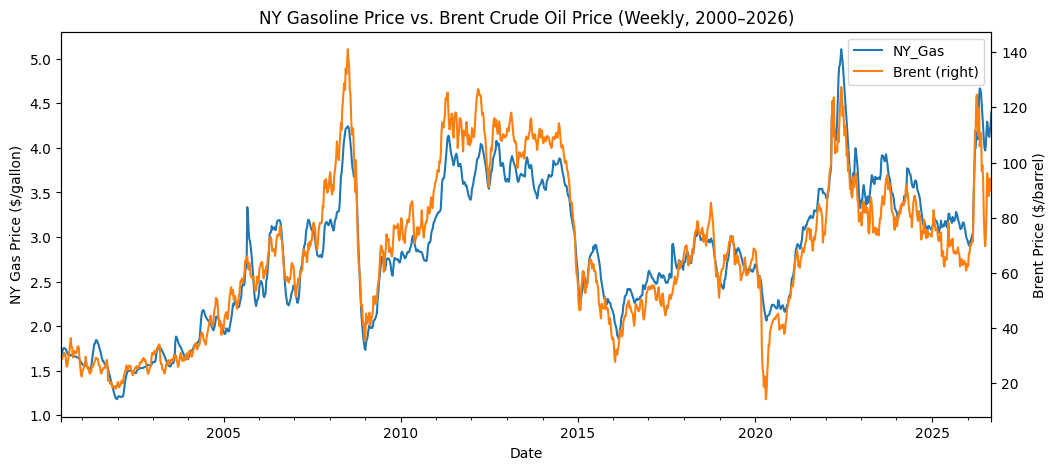

In [11]:
#Plotting Brent Crude and NY Gas Prices 2000-2026
ax = df.set_index('Date')[['NY_Gas', 'Brent']].plot(secondary_y='Brent', figsize=(12,5))

ax.set_title('NY Gasoline Price vs. Brent Crude Oil Price (Weekly, 2000–2026)')
ax.set_xlabel('Date')
ax.set_ylabel('NY Gas Price ($/gallon)')
ax.right_ax.set_ylabel('Brent Price ($/barrel)')

plt.show()


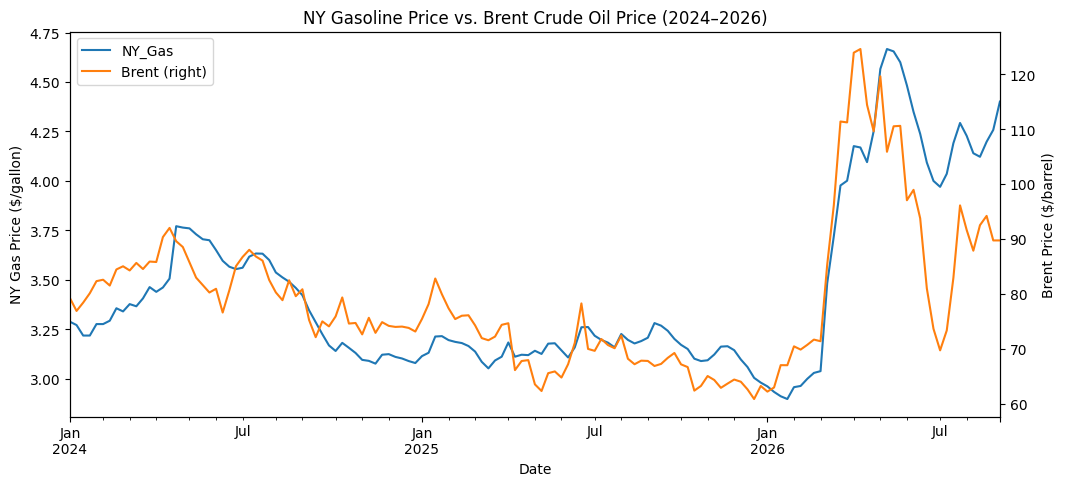

In [18]:
#Plotting Brent Crude and NY Gas Prices 2024-2026
df_post2024 = df.loc['2024-01-01':'2026-12-31'].copy()

ax2 = df_post2024[['NY_Gas', 'Brent']].plot(secondary_y='Brent', figsize=(12,5))

ax2.set_title('NY Gasoline Price vs. Brent Crude Oil Price (2024–2026)')
ax2.set_xlabel('Date')
ax2.set_ylabel('NY Gas Price ($/gallon)')
ax2.right_ax.set_ylabel('Brent Price ($/barrel)')

plt.show()

In [19]:
#Asymmetric Passthrough Regression Analysis 2000-2026
# Week-over-week change in Brent
df['Brent_change'] = df['Brent'].diff()

# Split into rising vs. falling weeks
rising = df[df['Brent_change'] > 0].copy()
falling = df[df['Brent_change'] < 0].copy()

# Regression during RISING weeks
X_rising = sm.add_constant(rising['Brent'])
y_rising = rising['NY_Gas']
model_rising = sm.OLS(y_rising, X_rising, missing='drop').fit()

# Regression during FALLING weeks
X_falling = sm.add_constant(falling['Brent'])
y_falling = falling['NY_Gas']
model_falling = sm.OLS(y_falling, X_falling, missing='drop').fit()

# Summary table
comparison = pd.DataFrame({
    'Rising Crude Weeks': [model_rising.params['Brent'], model_rising.rsquared, len(rising)],
    'Falling Crude Weeks': [model_falling.params['Brent'], model_falling.rsquared, len(falling)]
}, index=['Brent Coefficient', 'R-squared', 'N (weeks)'])

comparison

,Rising Crude Weeks,Falling Crude Weeks
Brent Coefficient,0.026564,0.026002
R-squared,0.895500,0.880472
N (weeks),732.000000,635.000000


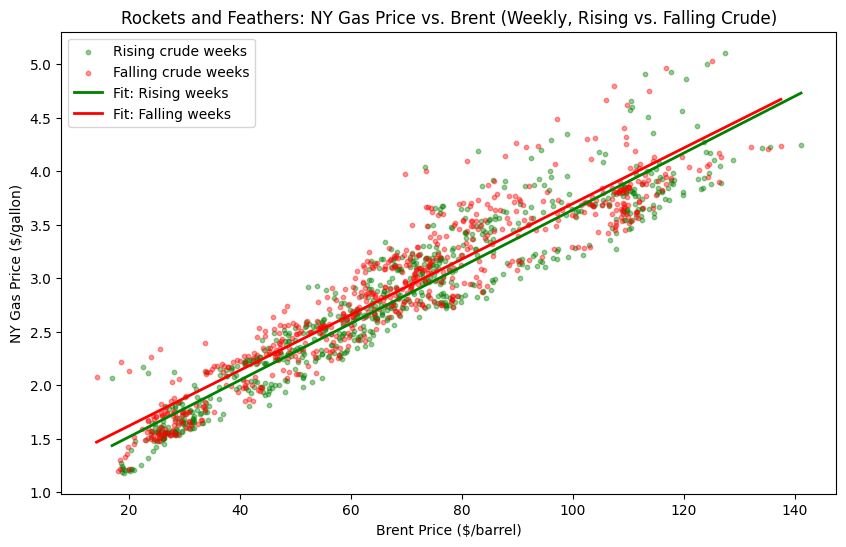

In [20]:
#Assymetric Passthrough Graph 2000-2026
fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(rising['Brent'], rising['NY_Gas'], color='green', alpha=0.4, label='Rising crude weeks', s=10)
ax.scatter(falling['Brent'], falling['NY_Gas'], color='red', alpha=0.4, label='Falling crude weeks', s=10)

brent_range_rising = pd.Series(sorted(rising['Brent'].dropna().unique()))
brent_range_falling = pd.Series(sorted(falling['Brent'].dropna().unique()))

pred_rising = model_rising.predict(sm.add_constant(brent_range_rising))
pred_falling = model_falling.predict(sm.add_constant(brent_range_falling))

ax.plot(brent_range_rising, pred_rising, color='green', linewidth=2, label='Fit: Rising weeks')
ax.plot(brent_range_falling, pred_falling, color='red', linewidth=2, label='Fit: Falling weeks')

ax.set_title('Rockets and Feathers: NY Gas Price vs. Brent (Weekly, Rising vs. Falling Crude)')
ax.set_xlabel('Brent Price ($/barrel)')
ax.set_ylabel('NY Gas Price ($/gallon)')
ax.legend()

plt.show()

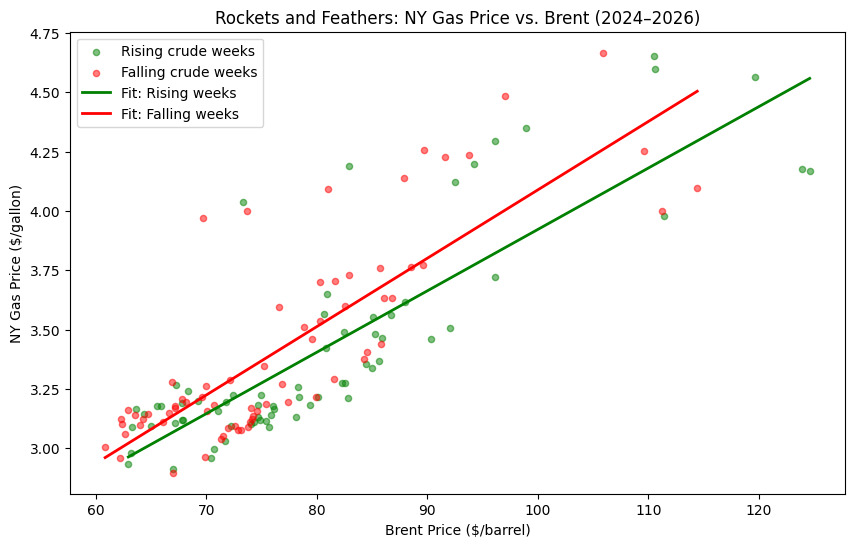

In [21]:
#Assymetric Passthrough Graph 2024-2026
# Week-over-week Brent change, computed within this subset
df_post2024['Brent_change'] = df_post2024['Brent'].diff()

rising_recent = df_post2024[df_post2024['Brent_change'] > 0].copy()
falling_recent = df_post2024[df_post2024['Brent_change'] < 0].copy()

X_rising_recent = sm.add_constant(rising_recent['Brent'])
model_rising_recent = sm.OLS(rising_recent['NY_Gas'], X_rising_recent, missing='drop').fit()

X_falling_recent = sm.add_constant(falling_recent['Brent'])
model_falling_recent = sm.OLS(falling_recent['NY_Gas'], X_falling_recent, missing='drop').fit()

fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(rising_recent['Brent'], rising_recent['NY_Gas'], color='green', alpha=0.5, label='Rising crude weeks', s=20)
ax.scatter(falling_recent['Brent'], falling_recent['NY_Gas'], color='red', alpha=0.5, label='Falling crude weeks', s=20)

brent_range_rising = pd.Series(sorted(rising_recent['Brent'].dropna().unique()))
brent_range_falling = pd.Series(sorted(falling_recent['Brent'].dropna().unique()))

pred_rising = model_rising_recent.predict(sm.add_constant(brent_range_rising))
pred_falling = model_falling_recent.predict(sm.add_constant(brent_range_falling))

ax.plot(brent_range_rising, pred_rising, color='green', linewidth=2, label='Fit: Rising weeks')
ax.plot(brent_range_falling, pred_falling, color='red', linewidth=2, label='Fit: Falling weeks')

ax.set_title('Rockets and Feathers: NY Gas Price vs. Brent (2024–2026)')
ax.set_xlabel('Brent Price ($/barrel)')
ax.set_ylabel('NY Gas Price ($/gallon)')
ax.legend()

plt.show()